# ILUSTR 2 — Czy O(n³) to teoretyczna granica? Algorytm Strassena

W konspekcie (rozdział 1) jest mowa o tym, że bezpośrednie rozwiązywanie/odwracanie układu wymaga rzędu $O(n^3)$ operacji, i że jest to **najlepszy znany, ogólny sposób** — ale nie jedyny teoretycznie możliwy. Ten notebook pokazuje to konkretnie na przykładzie **mnożenia macierzy** (na którym opiera się m.in. eliminacja Gaussa).

Nie chodzi o to, żeby nauczyć się algorytmu Strassena na pamięć — wystarczy zobaczyć, że **taki algorytm istnieje i realnie liczy mniej mnożeń** niż podejście "podręcznikowe" $O(n^3)$, mimo że oba dają ten sam wynik.

In [1]:
import numpy as np

def mnozenie_naiwne(A, B):
    # "Podręcznikowe" mnożenie macierzy: każdy element wyniku to suma iloczynów --
    # to dokładnie n^3 mnożeń skalarnych dla macierzy n x n.
    n = A.shape[0]
    C = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i, j] += A[i, k] * B[k, j]
    return C

n_test = 32
rng = np.random.RandomState(0)
A_test = rng.rand(n_test, n_test)
B_test = rng.rand(n_test, n_test)

C_naiwne = mnozenie_naiwne(A_test, B_test)
C_numpy = A_test @ B_test
print("Maks. różnica względem np.dot:", np.max(np.abs(C_naiwne - C_numpy)))

Maks. różnica względem np.dot: 3.552713678800501e-15


## Algorytm Strassena

Pomysł (Strassen, 1969): macierz $n\times n$ dzielimy na 4 bloki $n/2 \times n/2$ i zamiast **8** mnożeń bloków (jak w naiwnym podejściu blokowym) liczymy tylko **7** sprytnie skonstruowanych kombinacji, kosztem dodatkowych dodawań/odejmowań (dużo tańszych niż mnożenia). Zastosowany rekurencyjnie, daje złożoność $O(n^{\log_2 7}) \approx O(n^{2.807})$ zamiast $O(n^3)$.

Poniższy kod implementuje ten podział rekurencyjnie (dla macierzy o rozmiarze będącym potęgą 2 — w praktycznych bibliotekach dogania się to dopełnieniem zerami do najbliższej potęgi 2). Nie trzeba rozumieć każdej z 7 formuł osobno — ważny jest efekt: mniej mnożeń.

In [2]:
def strassen(A, B, prog=32):
    n = A.shape[0]
    if n <= prog:
        # Dla małych macierzy narzut rekurencji przewyższa zysk -- liczymy wprost.
        return A @ B

    polowa = n // 2
    A11, A12, A21, A22 = A[:polowa, :polowa], A[:polowa, polowa:], A[polowa:, :polowa], A[polowa:, polowa:]
    B11, B12, B21, B22 = B[:polowa, :polowa], B[:polowa, polowa:], B[polowa:, :polowa], B[polowa:, polowa:]

    # 7 rekurencyjnych mnożeń (zamiast 8) -- to jest sedno oszczędności Strassena
    M1 = strassen(A11 + A22, B11 + B22, prog)
    M2 = strassen(A21 + A22, B11, prog)
    M3 = strassen(A11, B12 - B22, prog)
    M4 = strassen(A22, B21 - B11, prog)
    M5 = strassen(A11 + A12, B22, prog)
    M6 = strassen(A21 - A11, B11 + B12, prog)
    M7 = strassen(A12 - A22, B21 + B22, prog)

    C11 = M1 + M4 - M5 + M7
    C12 = M3 + M5
    C21 = M2 + M4
    C22 = M1 - M2 + M3 + M6

    return np.block([[C11, C12], [C21, C22]])

n_test2 = 128  # potęga 2, żeby podział na połowy zawsze wychodził równo
A_test2 = rng.rand(n_test2, n_test2)
B_test2 = rng.rand(n_test2, n_test2)
C_strassen = strassen(A_test2, B_test2, prog=32)
C_numpy2 = A_test2 @ B_test2
print("Maks. różnica Strassen vs np.dot:", np.max(np.abs(C_strassen - C_numpy2)))

Maks. różnica Strassen vs np.dot: 1.0658141036401503e-13


## Ile faktycznie mnożeń skalarnych to kosztuje?

Zamiast mierzyć czas (który zależy od sprzętu i narzutu samego Pythona), policzmy **dokładną liczbę mnożeń skalarnych** wynikającą z każdej z dwóch rekurencji — to jest to, co faktycznie różni obie klasy złożoności:

- naiwne: $M(n) = n^3$,
- Strassen: $M(n) = 7\,M(n/2)$ aż do progu bazowego, gdzie $M(n_0) = n_0^3$.

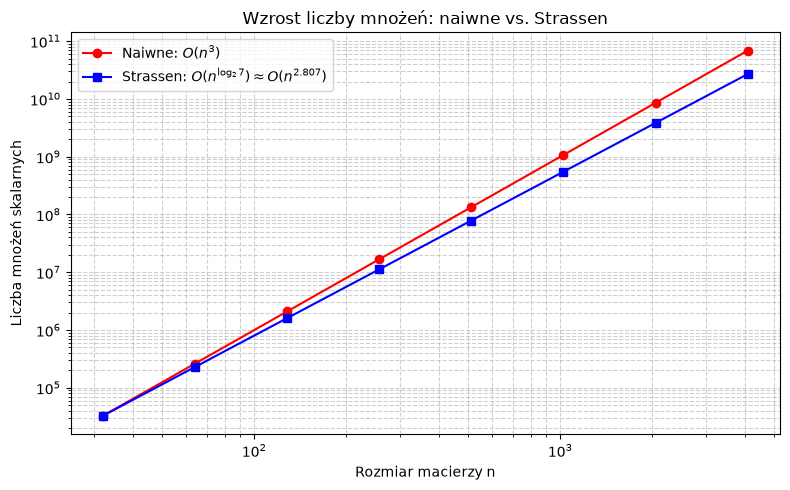

Dla n=4096: naiwne=6.872e+10, Strassen=2.699e+10, 2.55x mniej mnożeń


In [3]:
def liczba_mnozen_strassen(n, prog=32):
    # Sama rekurencja licząca liczbę mnożeń skalarnych -- bez faktycznego mnożenia macierzy,
    # więc możemy to policzyć nawet dla bardzo dużych n bez czekania na obliczenia.
    if n <= prog:
        return n ** 3
    return 7 * liczba_mnozen_strassen(n / 2, prog)

n_values = [2 ** k for k in range(5, 13)]   # od 32 do 4096

mnozenia_naiwne = [n ** 3 for n in n_values]
mnozenia_strassen = [liczba_mnozen_strassen(n, prog=32) for n in n_values]

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.loglog(n_values, mnozenia_naiwne, 'r-o', label='Naiwne: $O(n^3)$')
plt.loglog(n_values, mnozenia_strassen, 'b-s', label='Strassen: $O(n^{\\log_2 7}) \\approx O(n^{2.807})$')
plt.xlabel('Rozmiar macierzy n')
plt.ylabel('Liczba mnożeń skalarnych')
plt.title('Wzrost liczby mnożeń: naiwne vs. Strassen')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Dla n={n_values[-1]}: naiwne={mnozenia_naiwne[-1]:.3e}, Strassen={mnozenia_strassen[-1]:.3e}, "
      f"{mnozenia_naiwne[-1]/mnozenia_strassen[-1]:.2f}x mniej mnożeń")

## Najważniejsze wnioski

- $O(n^3)$ to **praktyczny kompromis**, nie ściana teoretyczna — Strassen (1969) i nowsze, nieomawiane tu warianty liczą mniej mnożeń dla dużych $n$.
- Rekordowy znany wykładnik teoretyczny jest dziś jeszcze niższy (ok. 2.37), ale takie algorytmy mają tak duże stałe/narzut, że **nie są używane w praktyce** dla realistycznych rozmiarów macierzy — dobra ilustracja różnicy między złożonością asymptotyczną a rzeczywistą wydajnością (patrz ćwiczenie niżej).
- To, że nie znamy (jeszcze) najlepszego możliwego algorytmu, nie oznacza, że problem jest "z natury" nierozwiązywalny szybciej — to zupełnie inna sytuacja niż faktycznie otwarte problemy matematyczne (np. hipoteza Riemanna).

## Wykorzystywane funkcje

| Funkcja | Opis |
|---|---|
| `A @ B` / `np.dot` | Zoptymalizowane (BLAS) mnożenie macierzy w numpy |
| `np.block([[...], [...]])` | Składa macierz blokową z podmacierzy |
| `A[:k, :k]` itp. | Wycinanie bloków macierzy (slicing) |

## ĆWICZENIE

1. Zmień próg bazowy `prog` w `strassen(...)` (np. na 8, 64, 128) i zmierz **rzeczywisty czas** działania na macierzy $1024\times 1024$ (funkcją `time.time()`) w porównaniu do `A @ B` z numpy. Który próg daje najlepszy czas? Dlaczego zbyt mały próg może pogorszyć wynik, mimo że teoretyczna liczba mnożeń wciąż maleje?
2. Dlaczego mimo mniejszej liczby mnożeń `strassen(...)` (napisany w czystym Pythonie, korzystający z numpy tylko na najniższym poziomie rekurencji) i tak przegrywa czasowo z `A @ B` z numpy? Co to mówi o różnicy między "złożonością obliczeniową" a "rzeczywistą wydajnością na konkretnym sprzęcie"?